<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치와 이상치 정리</span>

![ChatGPT Image 2026년 4월 22일 오전 10_22_51.png](<attachment:ChatGPT Image 2026년 4월 22일 오전 10_22_51.png>)
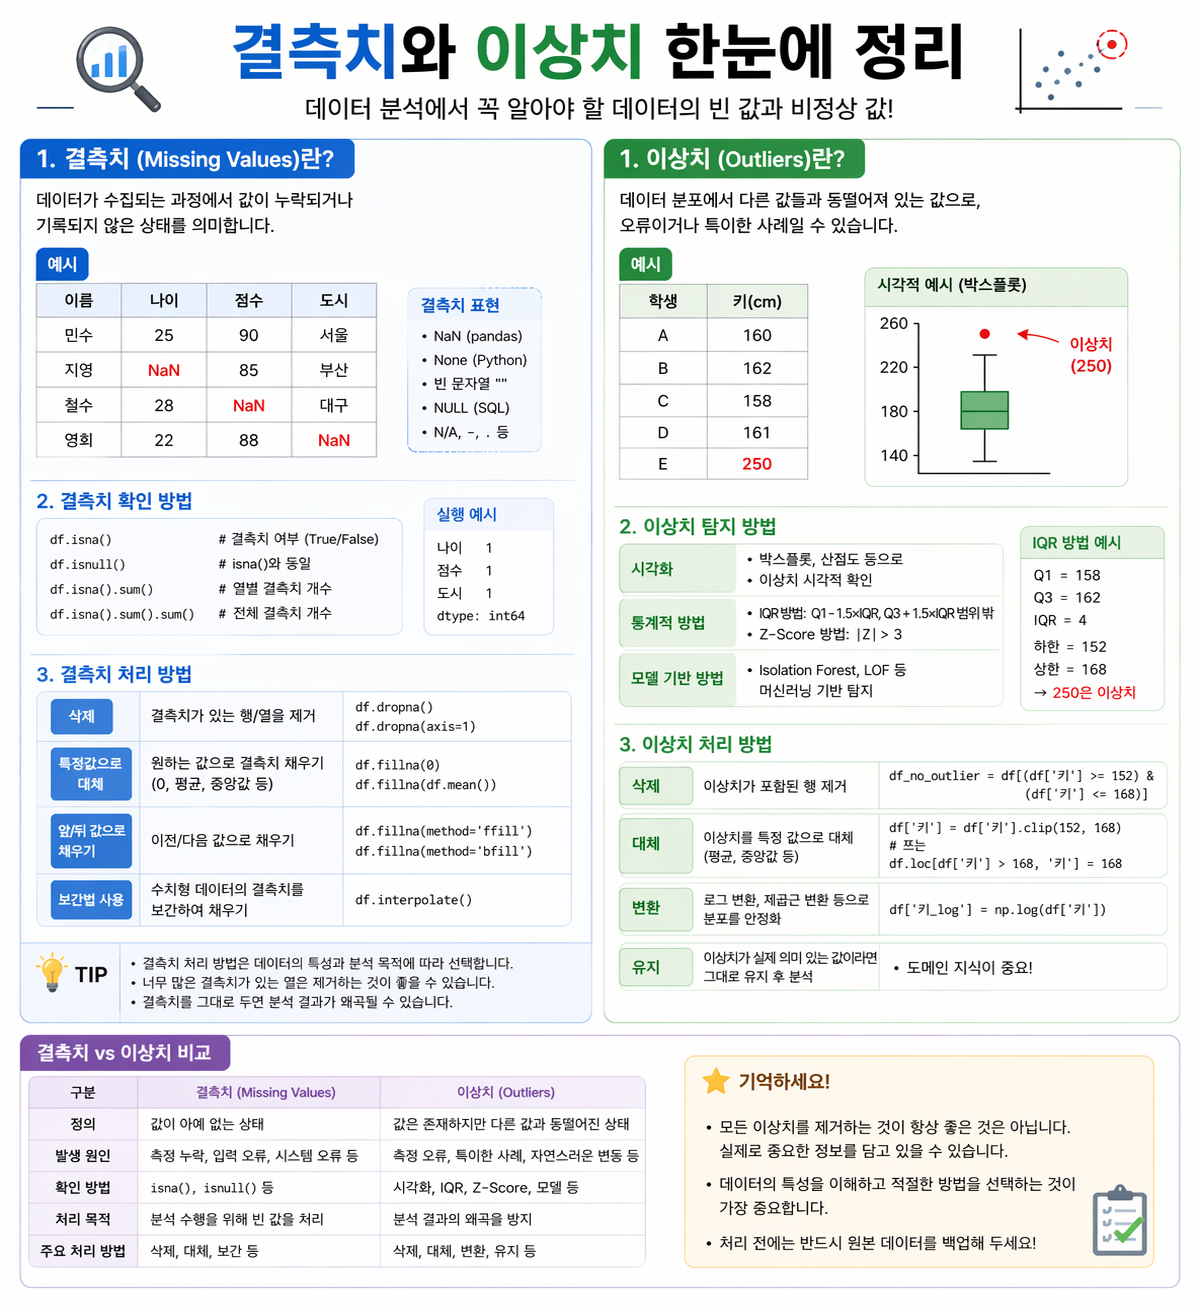

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치 만들기</span>

In [4]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    '이름': ['민수', '지영', '철수'],
    '나이': [25, np.nan, 28]
})

print(df)

   이름    나이
0  민수  25.0
1  지영   NaN
2  철수  28.0


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치 확인하기</span>

In [5]:
print(df.isna())        # True / False
print(df.isna().sum()) # 개수 확인

      이름     나이
0  False  False
1  False   True
2  False  False
이름    0
나이    1
dtype: int64


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치 제거하기</span>

In [6]:
print(df.dropna())  # NaN 있는 행 삭제

   이름    나이
0  민수  25.0
2  철수  28.0


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치 채우기</span>

In [7]:
print(df.fillna(0))          # 0으로 채우기
print(df.fillna(df.mean(numeric_only=True)))  # 평균값으로 채우기

   이름    나이
0  민수  25.0
1  지영   0.0
2  철수  28.0
   이름    나이
0  민수  25.0
1  지영  26.5
2  철수  28.0


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">결측치 앞/뒤 값으로 채우기</span>

In [14]:
# 기존: print(df.fillna(method='ffill'))
print(df.ffill())  # 앞 값으로 채움 (Forward Fill)

# 기존: print(df.fillna(method='bfill'))
print(df.bfill())  # 뒤 값으로 채움 (Backward Fill)

   이름    나이
0  민수  25.0
1  지영  25.0
2  철수  28.0
   이름    나이
0  민수  25.0
1  지영  28.0
2  철수  28.0


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">이상치 데이터 만들기</span>

In [9]:
df2 = pd.DataFrame({
    '키': [160, 162, 158, 161, 250]  # 250이 이상치
})

print(df2)

     키
0  160
1  162
2  158
3  161
4  250


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">이상치 탐지(IQR 방식)</span>

In [10]:
Q1 = df2['키'].quantile(0.25)
Q3 = df2['키'].quantile(0.75)
IQR = Q3 - Q1

outlier = df2[(df2['키'] < Q1 - 1.5*IQR) | (df2['키'] > Q3 + 1.5*IQR)]
print(outlier)

     키
4  250


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">이상치 제거하기</span>

In [11]:
df_no_outlier = df2[(df2['키'] >= Q1 - 1.5*IQR) & (df2['키'] <= Q3 + 1.5*IQR)]
print(df_no_outlier)

     키
0  160
1  162
2  158
3  161


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">이상치 값 제한하기(클리핑)</span>

In [12]:
df2['키'] = df2['키'].clip(150, 170)
print(df2)

     키
0  160
1  162
2  158
3  161
4  170
